# Aufgabe 1

Bei Aufgabe 1 war es die Aufgabe die Entladung eines Kondensators im RC Kreis für 5 verschiedene Widerstände zu messen. Die Schaltung sah wie folgt aus:
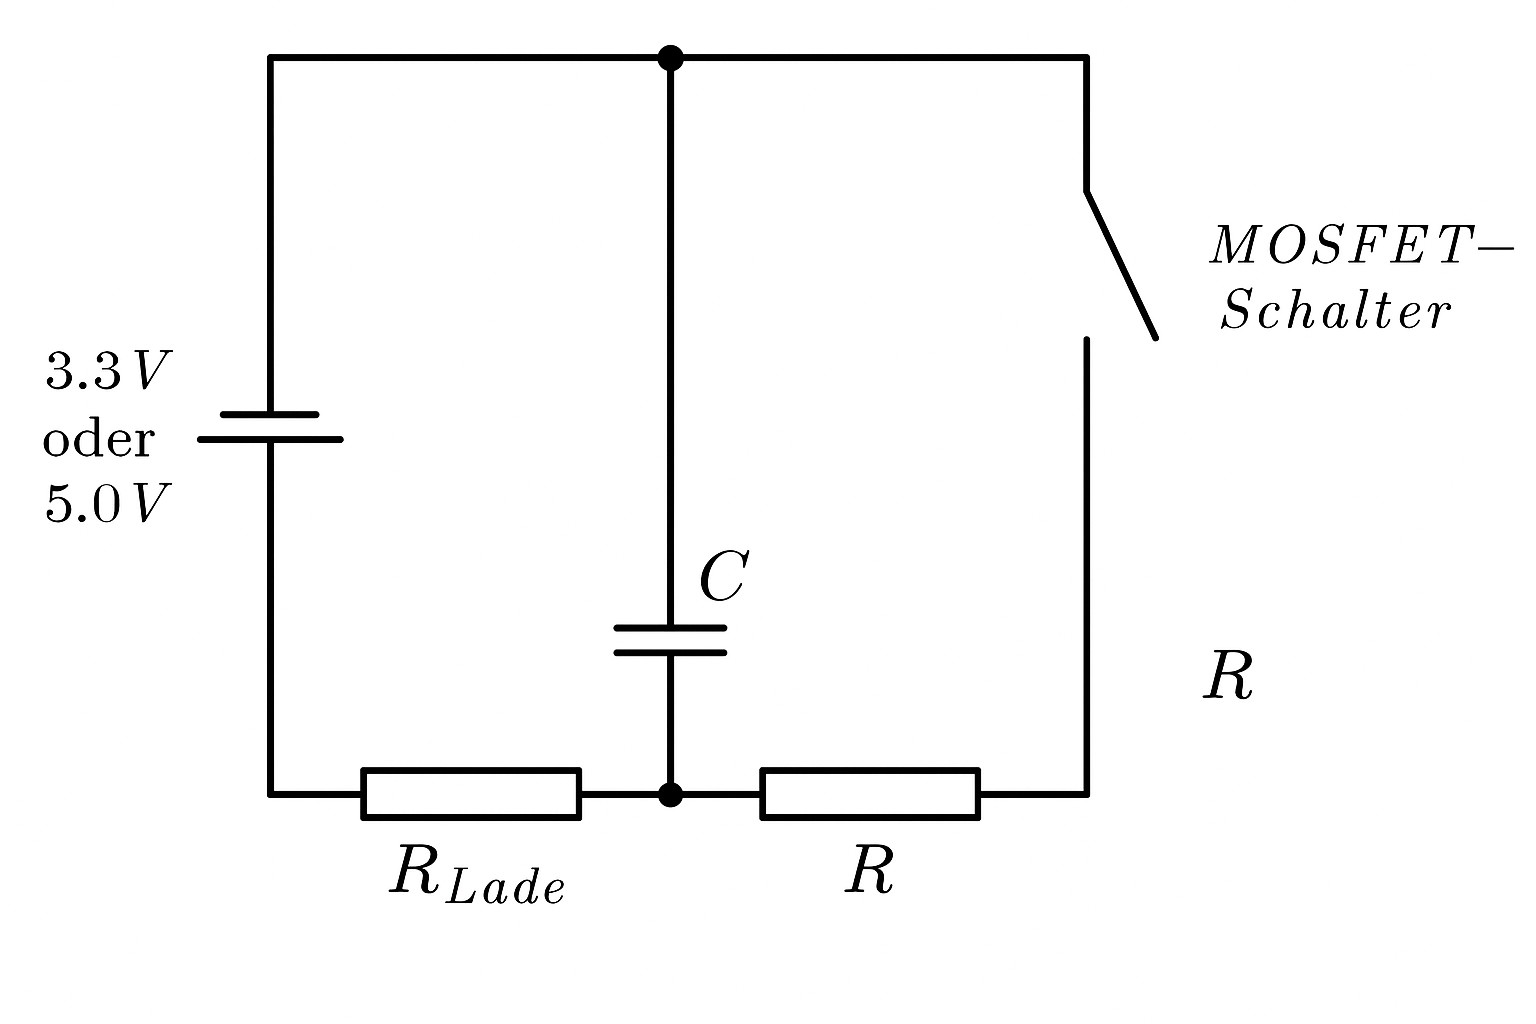

Der Widerstand $R_{lade}$ blieb dafür die ganze Zeit gleich und R wurde ausgetauscht. Genutzt haben wir dafür $R_{lade} = 986 \Omega$ und für $R$:
|Messung |R[$\Omega$]|
| ------------------------------------------- | --------------------------------------- |
| 1                            | 1,3                            | 
| 2                            | 10                              | 
| 3                           | 99,2                              | 
| 4                           | 217,3                               | 
| 5                            | 989                              | 

Der Arduino hat in der Schaltung in den gleichen Zeitabständen immer wieder den MOSFET-Schalter geschaltet und das Picoscope hat die Spannung über den Kondensator gemessen. Durch die immer gleichen Zeitabstände konnte das Programm "Picoscope 7" die Kurve mit richtig gewähltem Trigger gut anzeigen und die Werte dann exportiert werden.

### Aufgabe 1: Entladung eines RC-Glieds

#### Ziel der Aufgabe

In dieser Aufgabe wird die zeitliche Entladung eines Kondensators über einen Widerstand untersucht. Aus den gemessenen Spannungsverläufen für verschiedene Widerstände soll die Zeitkonstante des RC-Glieds bestimmt und daraus die Kapazität des Kondensators berechnet werden. Zusätzlich wird geprüft, ob die bestimmte Kapazität für alle verwendeten Widerstände konsistent bleibt.

---

#### Theoretische Grundlagen

Betrachtet wird ein Kondensator mit der Kapazität \( C \), der über einen ohmschen Gesamtwiderstand \( R_\text{ges} \) entladen wird. Für die Kondensatorspannung \( U_C(t) \) gilt bei der Entladung:

$
U_C(t) = U_0 \,\exp\left(-\frac{t}{\tau}\right)
$

mit

$
\tau = R_\text{ges} \cdot C
$

und

- \( U_0 \): Anfangsspannung am Kondensator zum Zeitpunkt \( t = 0 \)
- \( \tau \): Zeitkonstante des RC-Glieds
- \( R_\text{ges} \): wirksamer Gesamtwiderstand im Entladezweig

Im vorliegenden Aufbau setzt sich der Gesamtwiderstand während der Entladung aus dem eingestellten Widerstand \( R \) und dem Ladewiderstand \( R_\text{Lade} \) zusammen:

$
R_\text{ges} = R + R_\text{Lade}
$

Durch Logarithmieren der Entladungsgleichung erhält man eine lineare Darstellung:

$
\ln\left(\frac{U_C(t)}{U_0}\right) = -\frac{t}{\tau}
$

Damit ergibt sich bei Auftragung von

$
y = \ln\left(\frac{U_C}{U_0}\right)
$

gegen die Zeit \( t \) eine Gerade der Form

$
y(t) = a \cdot t + b
$

mit

$
a = -\frac{1}{\tau} \quad \Rightarrow \quad \tau = -\frac{1}{a}
$

Kennt man den Gesamtwiderstand \( R_\text{ges} \), kann aus der bestimmten Zeitkonstante die Kapazität des Kondensators berechnet werden:

$
C = \frac{\tau}{R_\text{ges}}
$

---

#### Auswertungsvorschrift

1. Für jede Messung mit einem Widerstand \( R \) liegt eine CSV-Datei der Form  
   `Aufgabe1_...R.csv` im Ordner `Messwerte` vor, wobei  
   \(... = 1, 10, 100, 220, 1000\) den Widerstandswerten entsprechen.

2. Aus jeder CSV-Datei werden die Messpaare \( (t_i, U_{C,i}) \) eingelesen, wobei
   - \( t_i \): Zeitpunkte der Messung
   - \( U_{C,i} \): zugehörige Kondensatorspannungen

3. Die Anfangsspannung \( U_0 \) wird aus dem ersten Messpunkt (oder aus einem Mittelwert der ersten Punkte) bestimmt:

   $
   U_0 \approx U_{C}(t_0)
   $

4. Für jeden Messpunkt wird die logarithmierte Größe

   $
   y_i = \ln\left(\frac{U_{C,i}}{U_0}\right)
   $

   berechnet.

5. Die Werte \( y_i \) werden gegen die Zeit \( t_i \) aufgetragen und es wird eine lineare Ausgleichsrechnung durchgeführt:

   $
   y_i \approx a \cdot t_i + b
   $

6. Aus der Steigung \( a \) ergibt sich die Zeitkonstante:

   $
   \tau = -\frac{1}{a}
   $

7. Mit dem bekannten Gesamtwiderstand

   $
   R_\text{ges} = R + R_\text{Lade}
   $

   wird die Kapazität des Kondensators berechnet:

   $
   C = \frac{\tau}{R_\text{ges}}
   $

8. Die berechneten Werte für \( \tau \) und \( C \) werden für alle fünf Widerstände in einer Tabelle zusammengefasst und anschließend diskutiert. Insbesondere wird verglichen, ob die bestimmte Kapazität \( C \) für alle Widerstände innerhalb der Messunsicherheit übereinstimmt.


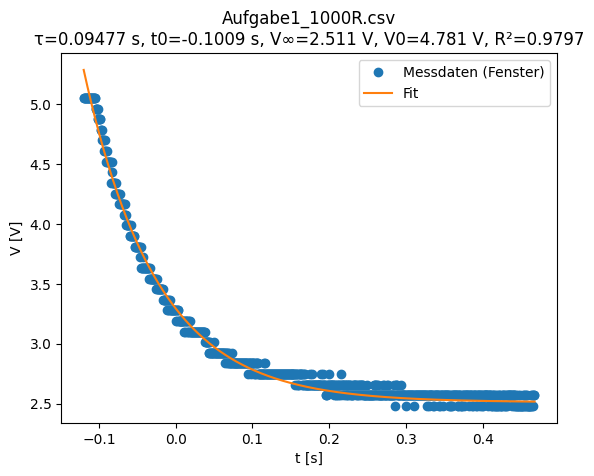

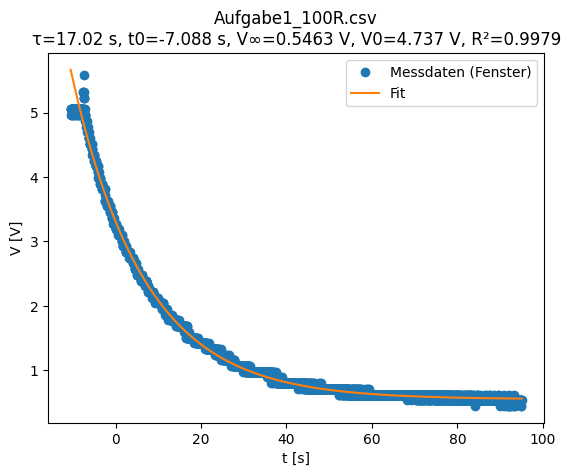

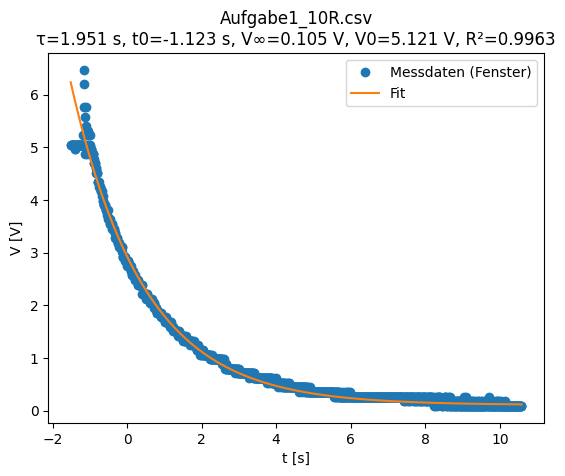

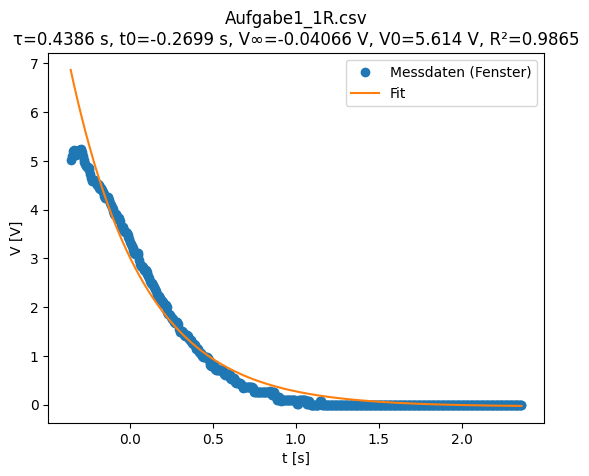

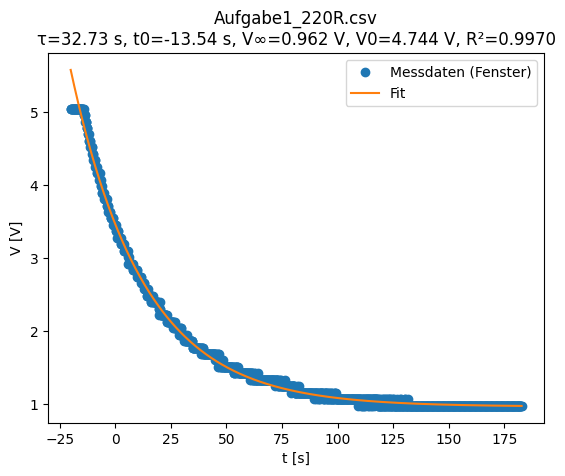

,file,R_ohm,tau_s,t0_s,C_est_F,fc_Hz,V_inf_V,V0_V,R2
0,Aufgabe1_1000R.csv,1000.0,0.094770,-0.100938,0.000095,1.679389,2.510858,4.781337,0.979711
1,Aufgabe1_100R.csv,100.0,17.016518,-7.087833,0.170165,0.009353,0.546270,4.737044,0.997931
2,Aufgabe1_10R.csv,10.0,1.951481,-1.122773,0.195148,0.081556,0.104989,5.121451,0.996296
3,Aufgabe1_1R.csv,1.0,0.438590,-0.269904,0.438590,0.362879,-0.040657,5.613894,0.986498
4,Aufgabe1_220R.csv,220.0,32.730435,-13.541850,0.148775,0.004863,0.962033,4.743729,0.997015


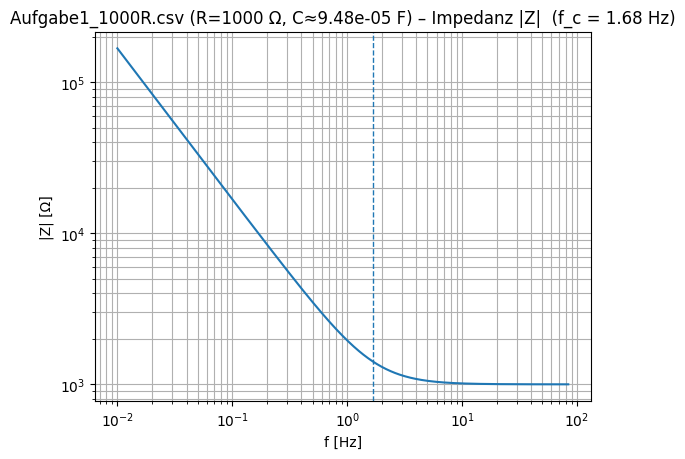

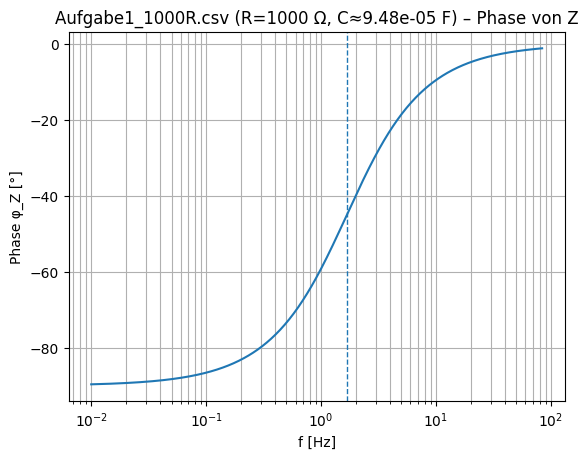

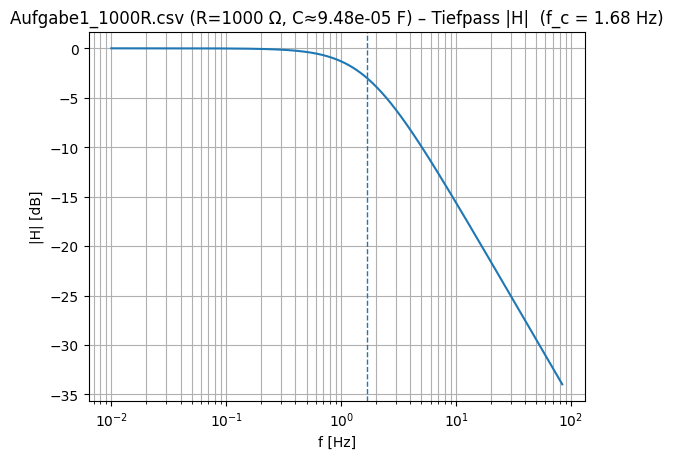

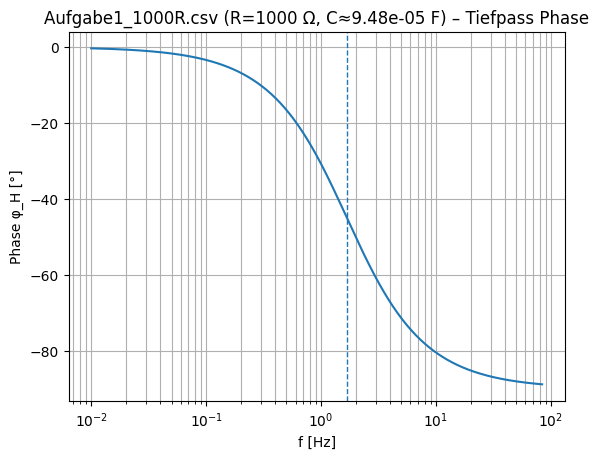

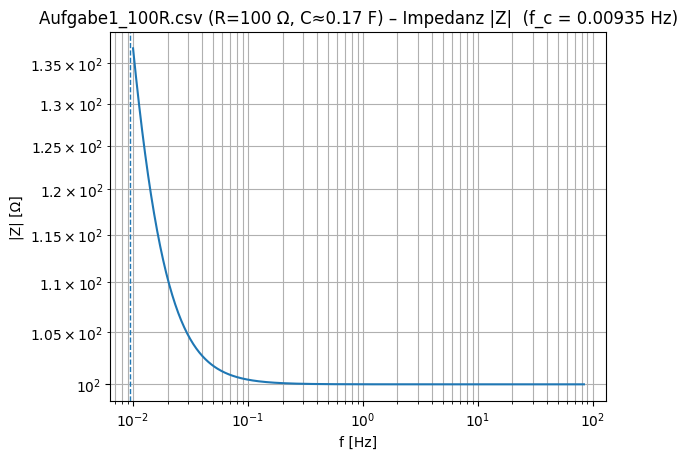

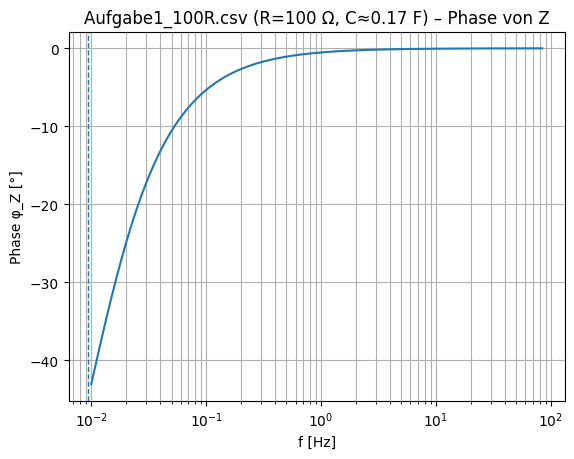

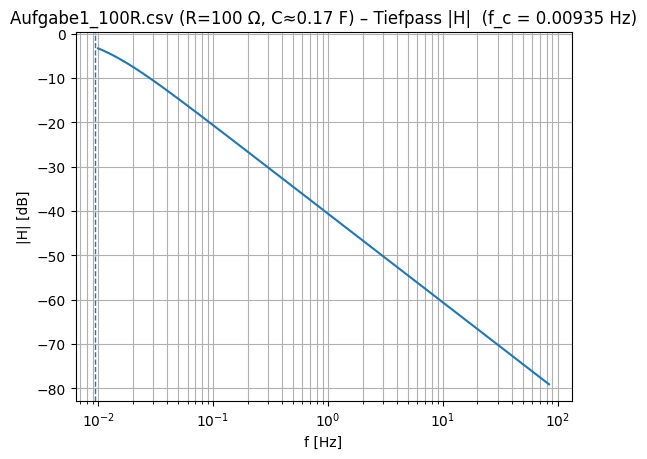

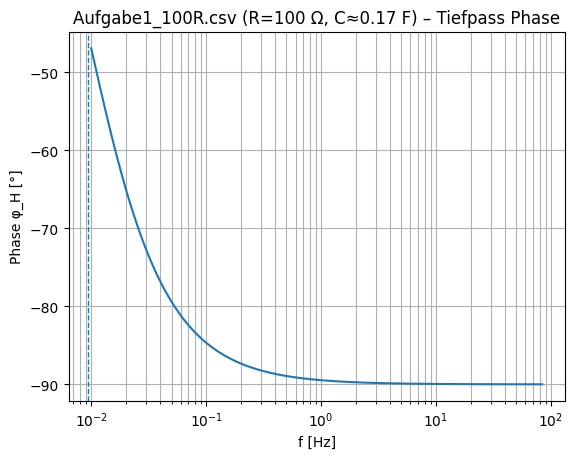

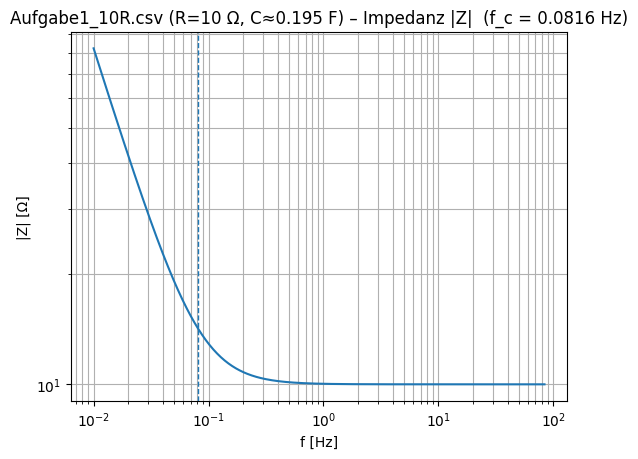

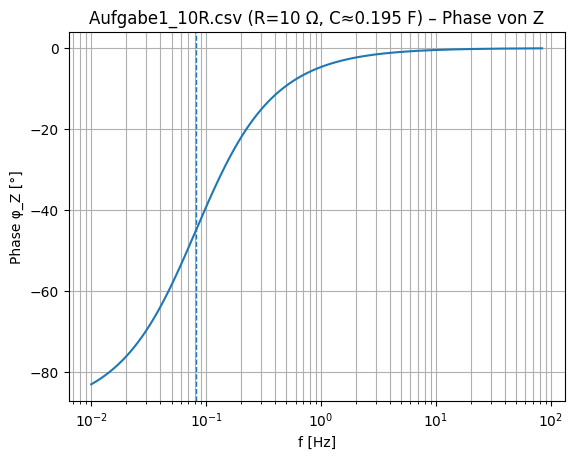

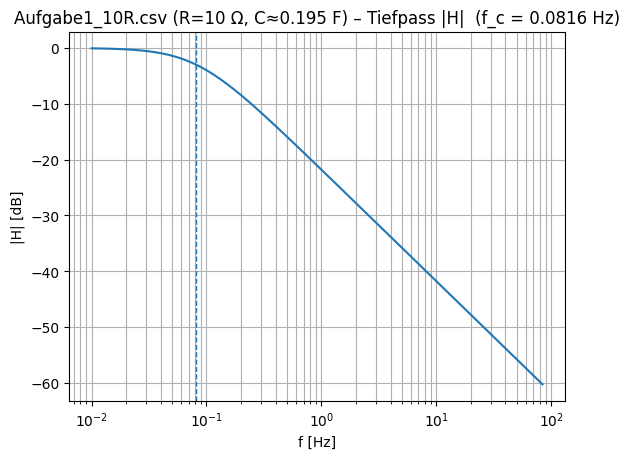

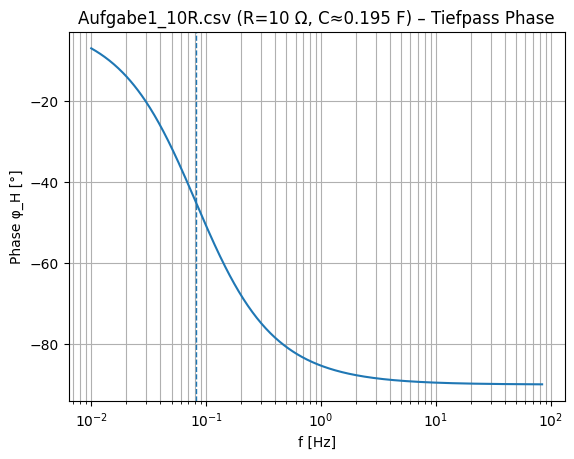

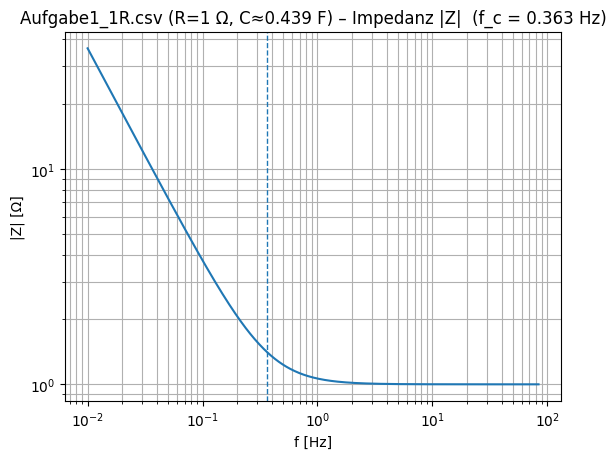

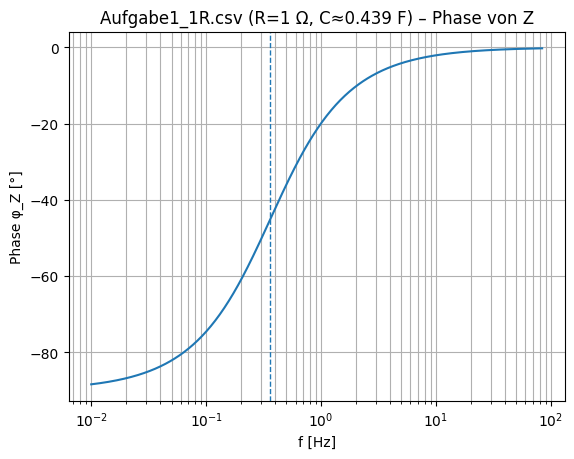

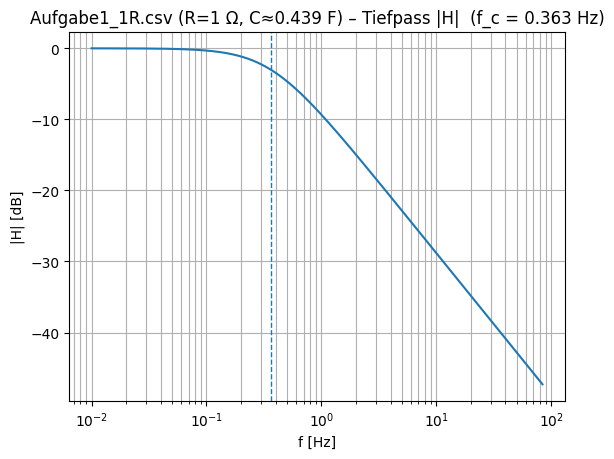

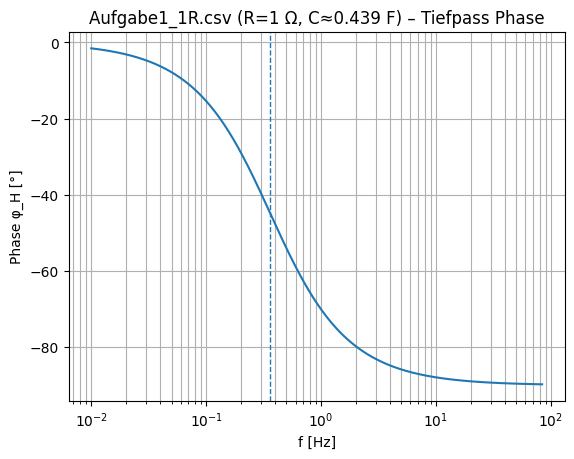

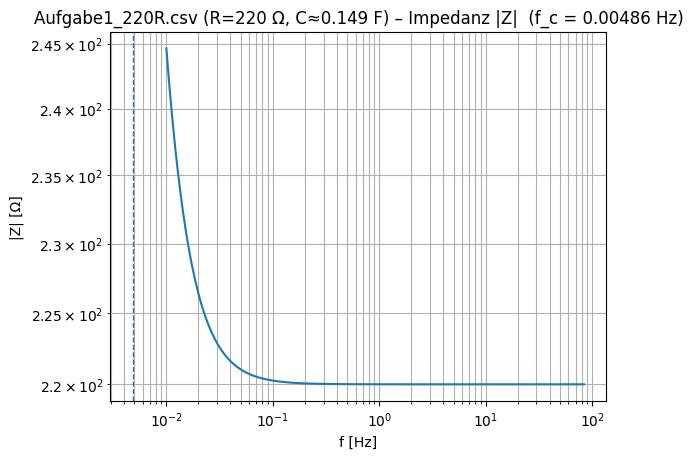

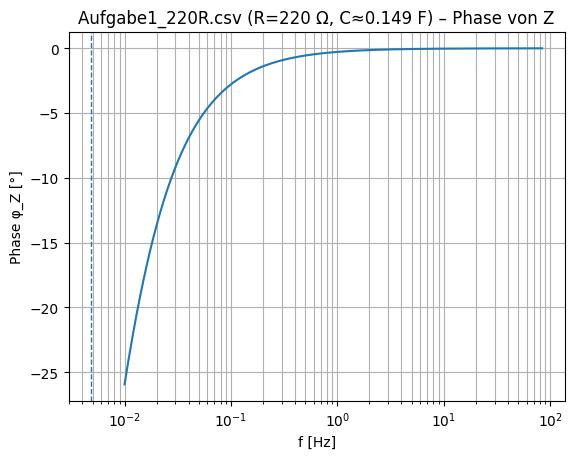

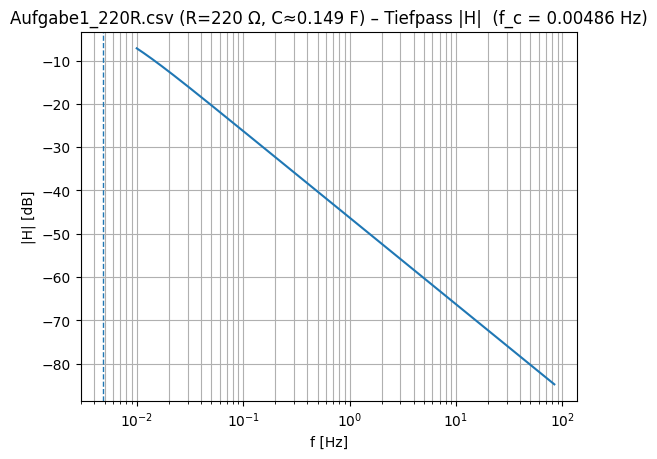

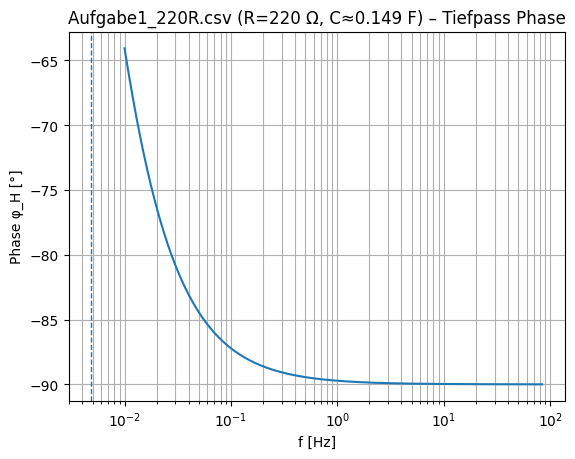

Kapazität (Median-Schätzer über Messungen): C ≈ 0.170165 F


In [3]:
# === RC-KREIS: Entladung fitten + Impedanz/Phase + Tiefpass-Bode (alles inline) ===

import os, glob, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import curve_fit
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# -------------------- Modell & Fit mit t0 --------------------

def rc_shift_model(t, V_inf, A, tau, t0):
    """V(t) = V_inf + A * exp(-(t - t0)/tau)"""
    return V_inf + A * np.exp(-(t - t0) / tau)

def detect_t0(t: np.ndarray, v: np.ndarray) -> float:
    """Entladestart t0: erster deutlicher Abfall ggü. Basislinie.
    Fallback: Zeitpunkt mit stärkstem negativen Gradient."""
    t = np.asarray(t).ravel(); v = np.asarray(v).ravel()
    order = np.argsort(t); t = t[order]; v = v[order]
    n = len(v); k = max(5, n//20)
    baseline = float(np.median(v[:k]))
    threshold = baseline - max(0.02*baseline, 0.05)  # 2% oder 50 mV
    below = np.where(v < threshold)[0]
    if len(below) > 0:
        return float(t[below[0]])
    dv = np.gradient(v, t)
    return float(t[int(np.argmin(dv))])

def fit_rc_discharge_shifted(t: np.ndarray, v: np.ndarray):
    """Fit: V_inf, A, tau, t0 + R^2 zurückgeben, inkl. (t,v) für Plots."""
    t = np.asarray(t, dtype=float).ravel(); v = np.asarray(v, dtype=float).ravel()
    order = np.argsort(t); t = t[order]; v = v[order]
    t0_guess = detect_t0(t, v)
    mask = t >= t0_guess
    t_fit = t[mask]; v_fit = v[mask]
    if len(t_fit) < 8:
        raise ValueError("Zu wenige Punkte im Entladebereich (t >= t0).")

    tail_k = max(5, len(v_fit)//10)
    V_inf0 = float(np.median(v_fit[-tail_k:]))
    A0 = float(v_fit[0] - V_inf0)
    mid = V_inf0 + 0.5*A0
    idx = np.where((v_fit[:-1] >= mid) & (v_fit[1:] < mid))[0]
    if len(idx) > 0:
        i = int(idx[0])
        t_half = t_fit[i] + (t_fit[i+1]-t_fit[i]) * (v_fit[i]-mid)/(v_fit[i]-v_fit[i+1] + 1e-12)
        tau0 = max(1e-6, (t_half - t_fit[0]) / np.log(2))
    else:
        tau0 = max(1e-6, (t_fit[-1] - t_fit[0]) / 5.0)

    if SCIPY_AVAILABLE:
        span = max(1e-9, t_fit[-1] - t_fit[0])
        bounds = ([-np.inf, -np.inf, 1e-9, t0_guess - 0.2*span],
                  [ np.inf,  np.inf, np.inf, t0_guess + 0.2*span])
        p0 = [V_inf0, A0, tau0, t0_guess]
        popt, _ = curve_fit(rc_shift_model, t_fit, v_fit, p0=p0, bounds=bounds, maxfev=30000)
        V_inf, A, tau, t0 = [float(x) for x in popt]
    else:
        # Fallback ohne Offset, aber mit t0-Shift
        t0 = float(t0_guess)
        t_rel = t_fit - t0
        mpos = v_fit > 0
        X = np.vstack([np.ones_like(t_rel[mpos]), -t_rel[mpos]]).T
        y = np.log(v_fit[mpos])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        lnV0, inv_tau = beta
        tau = 1.0/inv_tau if inv_tau != 0 else np.inf
        V_inf = 0.0
        A = float(np.exp(lnV0))

    v_hat = rc_shift_model(t_fit, V_inf, A, tau, t0)
    ss_res = float(np.nansum((v_fit - v_hat)**2))
    ss_tot = float(np.nansum((v_fit - np.nanmean(v_fit))**2))
    R2 = 1.0 - ss_res/ss_tot if ss_tot != 0 else np.nan

    return {"V_inf": V_inf, "A": A, "tau": tau, "t0": t0, "V0": V_inf + A, "R2": R2,
            "t": t, "v": v}

# -------------------- CSV laden --------------------

def load_time_voltage(csv_path: str):
    """Liest (Time, Channel A). Time in s; falls 'ms' im Namen, wird /1000."""
    import pandas as pd
    try:
        df = pd.read_csv(csv_path)
    except Exception:
        df = pd.read_csv(csv_path, sep=";")
    if "Time" not in df.columns or "Channel A" not in df.columns:
        # Fallback: erste zwei numerischen Spalten
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if len(numeric_cols) < 2:
            raise ValueError(f"Nicht genug numerische Spalten in {csv_path}")
        t = df[numeric_cols[0]].to_numpy(float)
        v = df[numeric_cols[1]].to_numpy(float)
        t_name = str(numeric_cols[0])
    else:
        t = df["Time"].to_numpy(float)
        v = df["Channel A"].to_numpy(float)
        t_name = "Time"
    if "ms" in t_name.lower():
        t = t/1000.0
    return t, v

# -------------------- Impedanz & Transferfunktion --------------------

def rc_impedance_series(R: float, C: float, f: np.ndarray):
    """Serien-RC: |Z| und Phase φ_Z (rad) über f [Hz]."""
    w = 2*np.pi*np.asarray(f, dtype=float)
    Zc = 1/(1j*w*C)
    Z = R + Zc
    mag = np.abs(Z)
    phi = np.angle(Z)            # < 0 (kapazitiv)
    return Z, mag, phi

def rc_lowpass_H(R: float, C: float, f: np.ndarray):
    """Tiefpass-Übertragungsfunktion H(jw) = 1/(1 + jwRC)."""
    w = 2*np.pi*np.asarray(f, dtype=float)
    H = 1/(1 + 1j*w*R*C)
    return np.abs(H), np.angle(H)

# -------------------- Plot-Helfer --------------------

def plot_discharge_fit_zoom(t, v, params, title_prefix=""):
    t0, tau = params["t0"], params["tau"]
    left = max(np.min(t), t0 - 0.2*tau)
    right = min(np.max(t), t0 + 6.0*tau)
    mask = (t >= left) & (t <= right)
    t_win, v_win = t[mask], v[mask]
    t_grid = np.linspace(left, right, 600)
    v_grid = rc_shift_model(t_grid, params["V_inf"], params["A"], tau, t0)

    plt.figure()
    plt.plot(t_win, v_win, "o", label="Messdaten (Fenster)")
    plt.plot(t_grid, v_grid, label="Fit")
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(f"{title_prefix}\nτ={tau:.4g} s, t0={t0:.4g} s, V∞={params['V_inf']:.4g} V, V0={params['V0']:.4g} V, R²={params['R2']:.4f}")
    plt.legend()
    plt.show()

def bode_range_from_taus(taus: np.ndarray):
    taus = np.asarray([t for t in taus if np.isfinite(t) and t>0], float)
    if len(taus) == 0:
        return np.logspace(-1, 3, 600)  # fallback 0.1..1k Hz
    f_min = 1/(2*np.pi*np.max(taus)*50)   # ~2 Dekaden unter kleinster fc
    f_max = 1/(2*np.pi*np.min(taus)/50)   # ~2 Dekaden über größter fc
    f_min = max(f_min, 1e-2); f_max = min(f_max, 1e6)
    return np.logspace(np.log10(f_min), np.log10(f_max), 600)

def plot_bode_impedance(R, C, fgrid, title_prefix=""):
    _, mag, phi = rc_impedance_series(R, C, fgrid)
    fc = 1.0/(2*np.pi*R*C)

    plt.figure()
    plt.loglog(fgrid, mag)
    plt.axvline(fc, linestyle="--", linewidth=1)
    plt.xlabel("f [Hz]"); plt.ylabel("|Z| [Ω]")
    plt.title(f"{title_prefix} – Impedanz |Z|  (f_c = {fc:.3g} Hz)")
    plt.grid(which="both")
    plt.show()

    plt.figure()
    plt.semilogx(fgrid, np.degrees(phi))
    plt.axvline(fc, linestyle="--", linewidth=1)
    plt.xlabel("f [Hz]"); plt.ylabel("Phase φ_Z [°]")
    plt.title(f"{title_prefix} – Phase von Z")
    plt.grid(which="both")
    plt.show()

def plot_bode_lowpass(R, C, fgrid, title_prefix=""):
    magH, phiH = rc_lowpass_H(R, C, fgrid)
    fc = 1.0/(2*np.pi*R*C)

    plt.figure()
    plt.semilogx(fgrid, 20*np.log10(magH))
    plt.axvline(fc, linestyle="--", linewidth=1)
    plt.xlabel("f [Hz]"); plt.ylabel("|H| [dB]")
    plt.title(f"{title_prefix} – Tiefpass |H|  (f_c = {fc:.3g} Hz)")
    plt.grid(which="both")
    plt.show()

    plt.figure()
    plt.semilogx(fgrid, np.degrees(phiH))
    plt.axvline(fc, linestyle="--", linewidth=1)
    plt.xlabel("f [Hz]"); plt.ylabel("Phase φ_H [°]")
    plt.title(f"{title_prefix} – Tiefpass Phase")
    plt.grid(which="both")
    plt.show()

# -------------------- Dateien & R aus Dateinamen --------------------

# Basismappe: Messwerte/ (Fallback: Messerte/)
base_dir = "Messwerte"
if not os.path.isdir(base_dir):
    base_dir = "Messerte"

# Alle Aufgabe1_*R.csv einsammeln
file_paths = sorted(glob.glob(os.path.join(base_dir, "Aufgabe1_*R.csv")))

def parse_R_from_filename(fname: str) -> float | None:
    """
    Extrahiert R aus z.B.
      Aufgabe1_1R.csv    -> 1 Ω
      Aufgabe1_220R.csv  -> 220 Ω
      Aufgabe1_1000R.csv -> 1000 Ω
      Aufgabe1_10kR.csv  -> 10 kΩ
      Aufgabe1_1MR.csv   -> 1 MΩ
    """
    base = os.path.basename(fname)
    m = re.search(r"_(\d+)\s*([kKmM]?)\s*[rR](?=\.csv$)", base)
    if not m:
        return None
    val = float(m.group(1))
    unit = m.group(2).lower()
    mult = 1.0 if unit=="" else (1e3 if unit=="k" else (1e6 if unit=="m" else 1.0))
    return val * mult

# -------------------- Pipeline: Fit, C, Plots --------------------

rows = []
for path in file_paths:
    t, v = load_time_voltage(path)
    params = fit_rc_discharge_shifted(t, v)
    plot_discharge_fit_zoom(t, v, params, title_prefix=os.path.basename(path))
    R = parse_R_from_filename(path)
    if R is not None and R > 0:
        C = params["tau"] / R
        fc = 1.0/(2*np.pi*R*C)
    else:
        C, fc = np.nan, np.nan
    rows.append({
        "file": os.path.basename(path),
        "R_ohm": R,
        "tau_s": params["tau"],
        "t0_s": params["t0"],
        "C_est_F": C,
        "fc_Hz": fc,
        "V_inf_V": params["V_inf"],
        "V0_V": params["V0"],
        "R2": params["R2"],
    })

df = pd.DataFrame(rows)
display(df)

# Bode-Bereich aus allen taus ableiten
def bode_range_from_taus(taus: np.ndarray):
    taus = np.asarray([t for t in taus if np.isfinite(t) and t>0], float)
    if len(taus) == 0:
        return np.logspace(-1, 3, 600)  # 0.1..1k Hz
    f_min = 1/(2*np.pi*np.max(taus)*50)
    f_max = 1/(2*np.pi*np.min(taus)/50)
    f_min = max(f_min, 1e-2); f_max = min(f_max, 1e6)
    return np.logspace(np.log10(f_min), np.log10(f_max), 600)

fgrid = bode_range_from_taus(df["tau_s"].to_numpy(float))

# Bode für jede Messung (Impedanz + Tiefpass)
for i, r in df.iterrows():
    R = r.get("R_ohm", np.nan)
    C = r.get("C_est_F", np.nan)
    if not (np.isfinite(R) and np.isfinite(C) and R>0 and C>0):
        continue
    tag = f"{r['file']} (R={R:g} Ω, C≈{C:.3g} F)"
    plot_bode_impedance(R, C, fgrid, title_prefix=tag)
    plot_bode_lowpass(R, C, fgrid, title_prefix=tag)

# Optional: C-Median anzeigen
C_valid = df["C_est_F"].dropna()
if len(C_valid) > 0:
    C_median = float(np.median(C_valid))
    print(f"Kapazität (Median-Schätzer über Messungen): C ≈ {C_median:.6g} F")
